<a target="_blank" href="https://colab.research.google.com/github/intensivedatacomp/image-processing/blob/main/examples/edge_detection_demo.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Edge Detection with the `image_processing` package

This notebook demonstrates the **elongated-mask edge detection** method from  
*Contour-texture separation: part 2* (Antal, 2024), implemented as a GPU-aware,
extendable PyTorch package.

### Method overview

1. A horizontal stripe of decaying values is placed on a blank canvas.
2. The canvas is rotated to `n_angles` orientations in `[0°, 180°)`.
3. Each rotated mask is **anti-symmetrised** by subtracting its 180° rotation,
   producing kernels sensitive to signed intensity gradients.
4. All kernels are applied to the image via `F.conv2d(padding='same')`.
5. The per-pixel response is aggregated with a **combination function**
   (e.g. sum of squares) to produce a single-channel edge map.

In [10]:
from dataclasses import dataclass
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import PIL.ImageOps
import torch
import torchvision.transforms

from image_processing import (
    BaseKernel,
    BaseKernelParams,
    EdgeDetector,
    ElongatedMaskKernel,
    ElongatedMaskParams,
    max_abs,
    sum_of_abs,
    sum_of_squares,
)
from image_processing.combination import sum_of_powers

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load or create a test image

Replace the path below with any image file, or keep the synthetic gradient image.

Image shape: torch.Size([3, 64, 64])  (C, H, W)


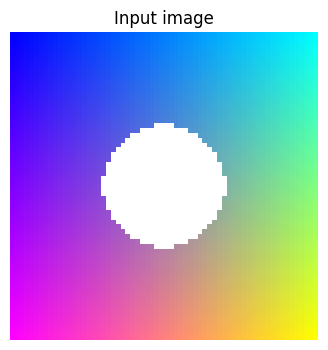

In [11]:
IMAGE_PATH = None  # set to a file path string to use a real image

if IMAGE_PATH is not None:
    pil_img = PIL.Image.open(IMAGE_PATH).convert("RGB")
    image = torchvision.transforms.ToTensor()(pil_img)[:3]  # (3, H, W)
else:
    # Synthetic image: gradient background + a sharp circle
    H, W = 64, 64
    xx, yy = torch.meshgrid(
        torch.linspace(0, 1, H), torch.linspace(0, 1, W), indexing="ij"
    )
    channel_r = xx
    channel_g = yy
    channel_b = 1 - xx * yy
    image = torch.stack([channel_r, channel_g, channel_b])  # (3, H, W)
    dist = ((xx - 0.5) ** 2 + (yy - 0.5) ** 2).sqrt()
    circle = (dist < 0.2).float()
    image = (image + circle.unsqueeze(0)).clamp(0, 1)

print(f"Image shape: {image.shape}  (C, H, W)")

pil_display = torchvision.transforms.ToPILImage()(image)
plt.figure(figsize=(4, 4))
plt.imshow(pil_display)
plt.title("Input image")
plt.axis("off")
plt.show()

## 2. Basic edge detection

Create an `EdgeDetector` with default parameters and run it.

Edge map shape  : torch.Size([64, 64])
Value range     : [0.0038, 1.0000]
Kernel shape    : torch.Size([10, 41, 41])  (n_angles, kH, kW)


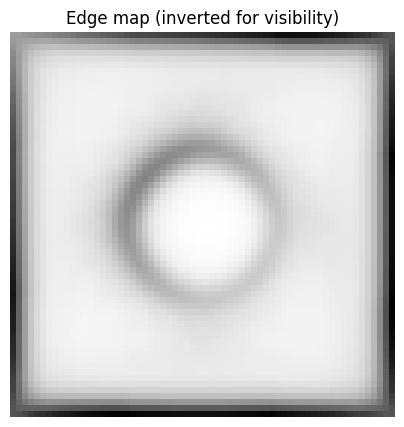

In [12]:
detector = EdgeDetector()  # GPU if available; sum_of_squares; normalize=True
edges = detector.detect(image)  # (H, W) in [0, 1]

print(f"Edge map shape  : {edges.shape}")
print(f"Value range     : [{edges.min():.4f}, {edges.max():.4f}]")
print(f"Kernel shape    : {detector.kernel.kernels.shape}  (n_angles, kH, kW)")

edges_cpu = edges.cpu()
plt.figure(figsize=(5, 5))
plt.imshow(
    PIL.ImageOps.invert(torchvision.transforms.ToPILImage()(edges_cpu)), cmap="gray"
)
plt.title("Edge map (inverted for visibility)")
plt.axis("off")
plt.show()

## 3. Visualising the oriented kernels

Each kernel is an anti-symmetric stripe rotated to a different angle.
Bright pixels have positive weight; dark pixels have negative weight.

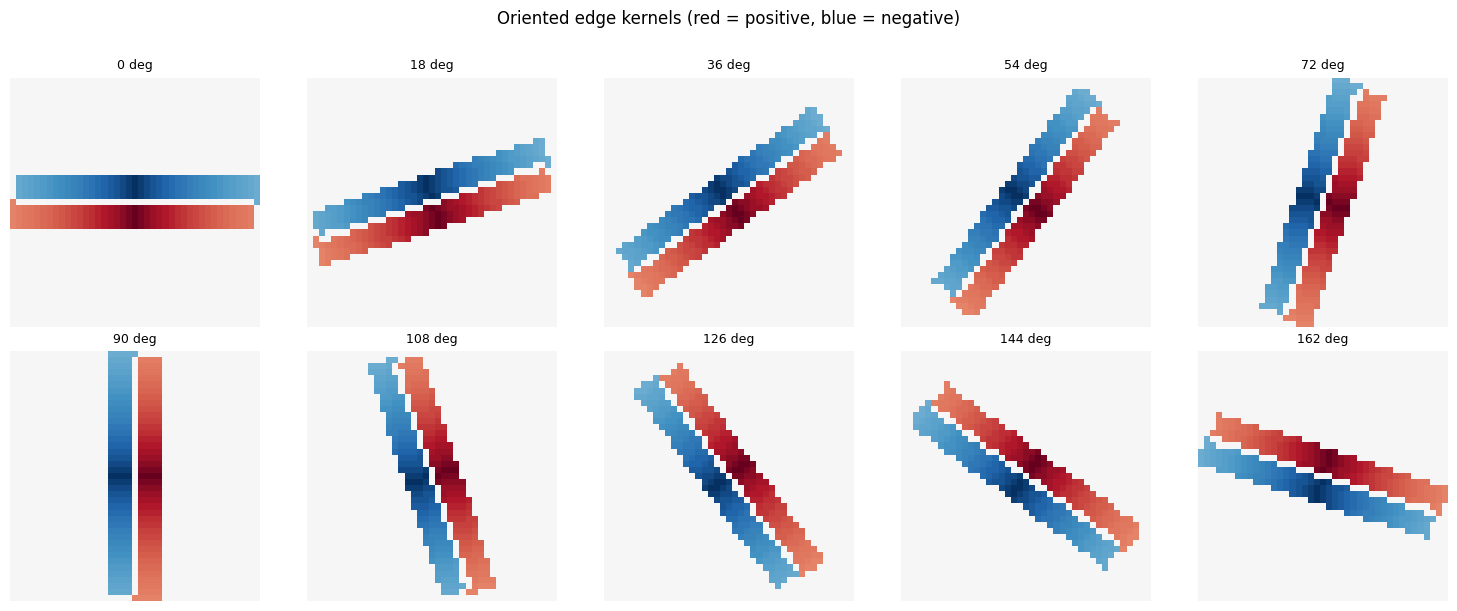

In [13]:
kernels = detector.kernel.kernels.cpu()  # (n_angles, kH, kW)
n = kernels.shape[0]
ncols = min(n, 5)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes_flat = np.array(axes).flatten()

# strict=False: axes_flat may have more slots than kernels (extra are hidden below)
for i, (ax, k) in enumerate(zip(axes_flat, kernels, strict=False)):
    angle = i * 180.0 / n
    vmax = k.abs().max().item()
    ax.imshow(k.numpy(), cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"{angle:.0f} deg", fontsize=9)
    ax.axis("off")
for ax in axes_flat[n:]:
    ax.set_visible(False)

plt.suptitle("Oriented edge kernels (red = positive, blue = negative)", y=1.01)
plt.tight_layout()
plt.show()

## 4. Comparing combination functions

The combination function controls how per-orientation responses are aggregated
into a final edge-strength map.

| Function | Formula | Behaviour |
|---|---|---|
| `sum_of_squares` | $\sum |r|^2$ | Emphasises strong edges |
| `sum_of_abs` | $\sum |r|$ | Equal weight to all edges |
| `max_abs` | $\max |r|$ | Peak response per pixel |
| `sum_of_powers(p)` | $\sum |r|^p$ | Tunable emphasis |

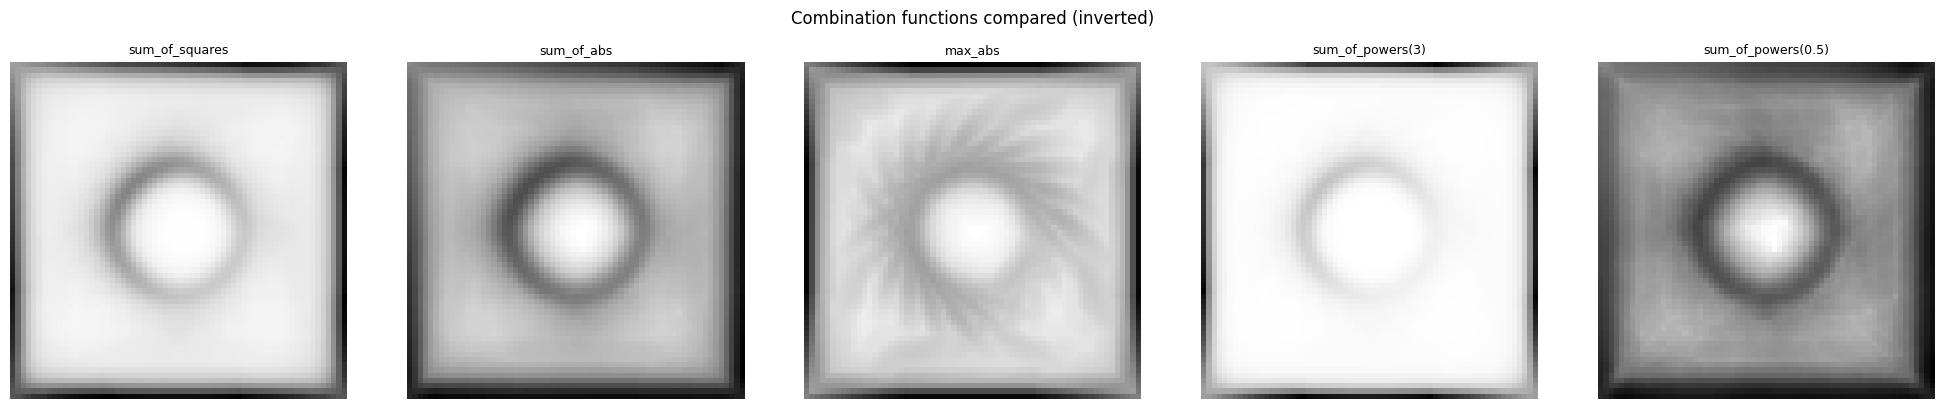

In [14]:
kernel_cpu = ElongatedMaskKernel(device="cpu")  # fixed kernel for fair comparison

fns = [
    ("sum_of_squares", sum_of_squares),
    ("sum_of_abs", sum_of_abs),
    ("max_abs", max_abs),
    ("sum_of_powers(3)", sum_of_powers(3.0)),
    ("sum_of_powers(0.5)", sum_of_powers(0.5)),
]

fig, axes = plt.subplots(1, len(fns), figsize=(4 * len(fns), 4))
for ax, (name, fn) in zip(axes, fns, strict=True):
    det = EdgeDetector(kernel=kernel_cpu, combine_fn=fn)
    out = det.detect(image.to("cpu"))
    ax.imshow(
        PIL.ImageOps.invert(torchvision.transforms.ToPILImage()(out.cpu())),
        cmap="gray",
    )
    ax.set_title(name, fontsize=9)
    ax.axis("off")

plt.suptitle("Combination functions compared (inverted)", y=1.01)
plt.tight_layout()
plt.show()

## 5. Customising kernel parameters

All kernel properties are exposed through `ElongatedMaskParams`.
The GPU example from the original notebook used 18 angles and a 61x61 kernel.

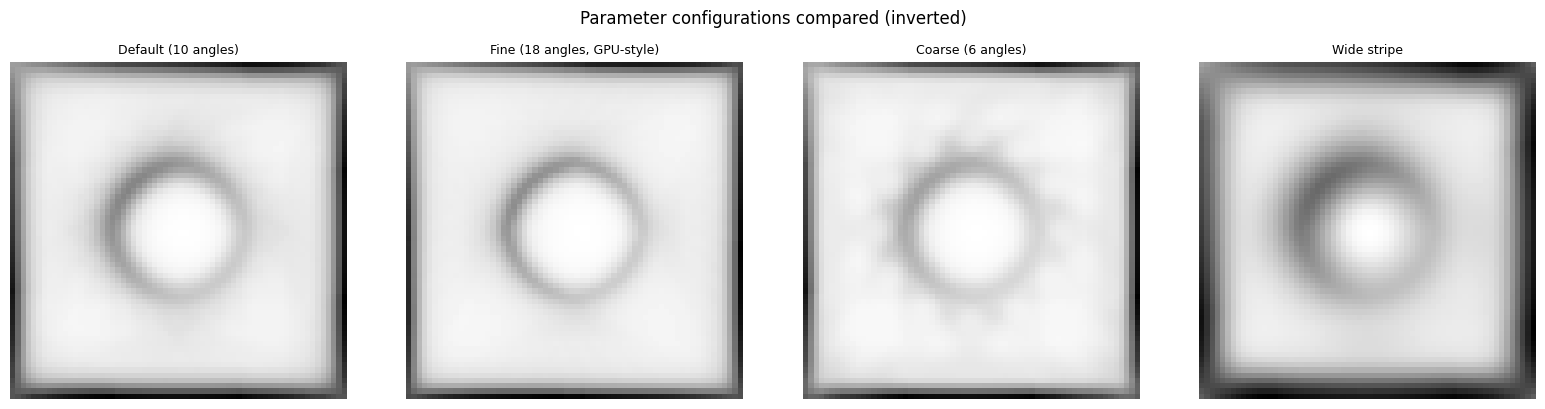

In [15]:
configs = [
    ("Default (10 angles)", ElongatedMaskParams()),
    (
        "Fine (18 angles, GPU-style)",
        ElongatedMaskParams(
            n_angles=18,
            kernel_half_size=30,
            stripe_half_width=5,
            stripe_half_length=30,
            length_falloff=0.1,
            width_falloff=1.0,
        ),
    ),
    ("Coarse (6 angles)", ElongatedMaskParams(n_angles=6)),
    ("Wide stripe", ElongatedMaskParams(stripe_half_width=10, stripe_half_length=15)),
]

fig, axes = plt.subplots(1, len(configs), figsize=(4 * len(configs), 4))
for ax, (label, params) in zip(axes, configs, strict=True):
    k = ElongatedMaskKernel(params, device="cpu")
    det = EdgeDetector(kernel=k)
    out = det.detect(image)
    ax.imshow(
        PIL.ImageOps.invert(torchvision.transforms.ToPILImage()(out.cpu())),
        cmap="gray",
    )
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.suptitle("Parameter configurations compared (inverted)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Batch detection

`detect_batch` processes a list of images with potentially different sizes.

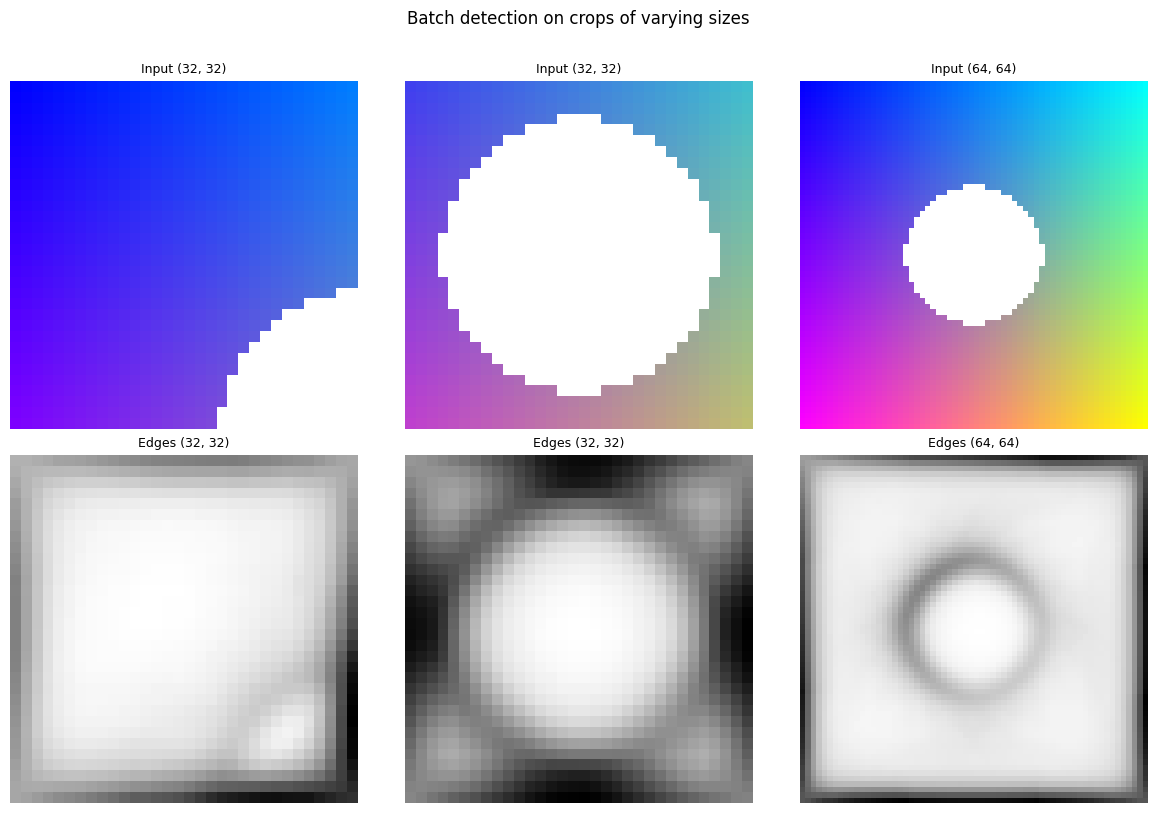

In [16]:
images = [
    image[:, :32, :32],  # top-left crop
    image[:, 16:48, 16:48],  # centre crop
    image,  # full image
]

maps = detector.detect_batch(images)

fig, axes = plt.subplots(2, len(images), figsize=(4 * len(images), 8))
for i, (img, emap) in enumerate(zip(images, maps, strict=True)):
    axes[0, i].imshow(torchvision.transforms.ToPILImage()(img.cpu()))
    axes[0, i].set_title(f"Input {tuple(img.shape[1:])}", fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(
        PIL.ImageOps.invert(torchvision.transforms.ToPILImage()(emap.cpu())),
        cmap="gray",
    )
    axes[1, i].set_title(f"Edges {tuple(emap.shape)}", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Batch detection on crops of varying sizes", y=1.01)
plt.tight_layout()
plt.show()

## 7. Extending with a custom kernel

Subclass `BaseKernel` to add a completely new kernel family.
The custom kernel plugs into `EdgeDetector` without any changes to the package.

Here we implement **Laplacian-of-Gaussian (LoG)** kernels at multiple scales.

In [17]:
@dataclass
class LogParams(BaseKernelParams):
    """Parameters for Laplacian-of-Gaussian kernels."""

    sigmas: tuple[float, ...] = (0.5, 1.0, 2.0, 4.0)


class LogKernel(BaseKernel):
    """Multi-scale Laplacian-of-Gaussian kernels."""

    def __init__(self, params=None, device=None):
        super().__init__(params or LogParams(), device)

    def build(self) -> torch.Tensor:
        p = cast(LogParams, self.params)
        half = p.kernel_half_size
        coords = np.arange(-half, half + 1, dtype=np.float64)
        yy, xx = np.meshgrid(coords, coords, indexing="ij")
        r2 = xx**2 + yy**2

        kernels = []
        for sigma in p.sigmas:
            s2 = sigma**2
            log = -1.0 / (np.pi * s2**2) * (1 - r2 / (2 * s2)) * np.exp(-r2 / (2 * s2))
            log -= log.mean()  # zero-mean so each kernel sums to ~0
            kernels.append(torch.from_numpy(log).float())

        return torch.stack(kernels).to(self.device)


log_kernel = LogKernel(
    LogParams(sigmas=(0.5, 1.0, 2.0, 4.0), kernel_half_size=20), device="cpu"
)
print(f"LoG kernel stack: {log_kernel.kernels.shape}")

LoG kernel stack: torch.Size([4, 41, 41])


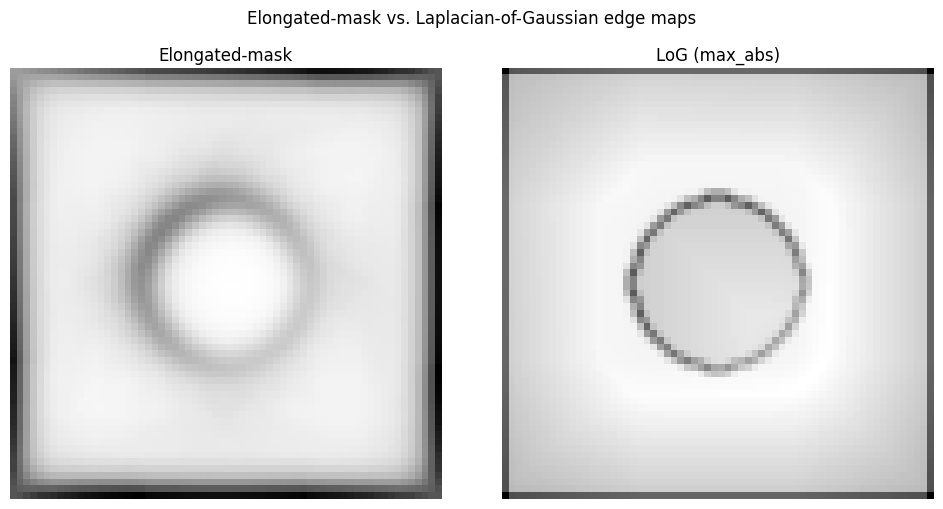

In [18]:
log_det = EdgeDetector(kernel=log_kernel, combine_fn=max_abs)
edges_log = log_det.detect(image)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (title, emap) in zip(
    axes,
    [
        ("Elongated-mask", edges.cpu()),
        ("LoG (max_abs)", edges_log.cpu()),
    ],
    strict=True,
):
    ax.imshow(
        PIL.ImageOps.invert(torchvision.transforms.ToPILImage()(emap)),
        cmap="gray",
    )
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Elongated-mask vs. Laplacian-of-Gaussian edge maps", y=1.01)
plt.tight_layout()
plt.show()